```mermaid
flowchart LR
    %% Main chain
    A((Sensor<br>b3f0)) --> B((Relay<br>de6c))
    B --> C((Relay<br>afc0))
    C --> D((Relay<br>f02c))
    D --> E((Sink<br>d110))

    %% New node connected bidirectionally
    A --> F((Relay<br>c998))
    F --> E
```
Linear Topology with 1 sender

C998 node was added later to the network


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.options.mode.chained_assignment = None 

In [12]:
nodes = ['afc0', 'b3f0', 'd110', 'de6c', 'f02c', 'c998']

for node in nodes:
    exec(f"{node} = pd.read_csv('./logs/logs2/{node}.log', sep = '>', header=None, names=['Timestamp', 'Message'])")

In [13]:
afc0['Id'] = "AFC0"
b3f0['Id'] = "B3F0"
d110['Id'] = "D110"
de6c['Id'] = "DE6C"
f02c['Id'] = "F02C"
c998['Id'] = "C998"

# Before Addition of C998

In [14]:
df = pd.concat([afc0, b3f0, d110, de6c, f02c], ignore_index=True)
df.head()

,Timestamp,Message,Id
0,19:38:12.432,[ 32002][V][LoraMesher.cpp:378] receivingRout...,AFC0
1,19:38:12.443,[ 32012][V][LoraMesher.cpp:379] receivingRout...,AFC0
2,19:38:12.450,[ 32019][I][PacketService.cpp:12] createEmpty...,AFC0
3,19:38:12.459,[ 32028][I][LoraMesher.cpp:392] receivingRout...,AFC0
4,19:38:12.470,[ 32039][V][LoraMesher.cpp:647] processPacket...,AFC0


In [15]:
df.dropna(subset=['Message'], inplace=True)

In [16]:
# convert timestamp to timestamp dtype
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

C:\Users\tripa\AppData\Local\Temp\ipykernel_6836\1537839190.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'])


In [17]:
df

,Timestamp,Message,Id
0,2025-07-29 19:38:12.432,[ 32002][V][LoraMesher.cpp:378] receivingRout...,AFC0
1,2025-07-29 19:38:12.443,[ 32012][V][LoraMesher.cpp:379] receivingRout...,AFC0
2,2025-07-29 19:38:12.450,[ 32019][I][PacketService.cpp:12] createEmpty...,AFC0
3,2025-07-29 19:38:12.459,[ 32028][I][LoraMesher.cpp:392] receivingRout...,AFC0
4,2025-07-29 19:38:12.470,[ 32039][V][LoraMesher.cpp:647] processPacket...,AFC0
...,...,...,...
14352,2025-07-29 20:08:02.619,[1822030][I][PacketQueueService.h:80] deleteQ...,F02C
14353,2025-07-29 20:08:02.627,[1822039][I][PacketQueueService.h:83] deleteQ...,F02C
14354,2025-07-29 20:08:02.637,[1822048][V][LoraMesher.cpp:658] processPacke...,F02C
14355,2025-07-29 20:08:02.646,[1822057][V][LoraMesher.cpp:641] processPacke...,F02C


In [18]:
before_c998 = df.copy()
c998['Timestamp'] = pd.to_datetime(c998['Timestamp'])
before_c998 = before_c998[before_c998['Timestamp'] < c998['Timestamp'].min()]
before_c998

C:\Users\tripa\AppData\Local\Temp\ipykernel_6836\2742278553.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  c998['Timestamp'] = pd.to_datetime(c998['Timestamp'])


,Timestamp,Message,Id
0,2025-07-29 19:38:12.432,[ 32002][V][LoraMesher.cpp:378] receivingRout...,AFC0
1,2025-07-29 19:38:12.443,[ 32012][V][LoraMesher.cpp:379] receivingRout...,AFC0
2,2025-07-29 19:38:12.450,[ 32019][I][PacketService.cpp:12] createEmpty...,AFC0
3,2025-07-29 19:38:12.459,[ 32028][I][LoraMesher.cpp:392] receivingRout...,AFC0
4,2025-07-29 19:38:12.470,[ 32039][V][LoraMesher.cpp:647] processPacket...,AFC0
...,...,...,...
13028,2025-07-29 19:55:51.734,[1091178][V][LoraMesher.cpp:455] waitBeforeSe...,F02C
13029,2025-07-29 19:55:52.447,[1091892][V][LoraMesher.cpp:754] printHeaderP...,F02C
13030,2025-07-29 19:55:52.551,[1091996][V][LoraMesher.cpp:575] sendPackets(...,F02C
13031,2025-07-29 19:55:52.561,[1092005][I][PacketQueueService.h:80] deleteQ...,F02C


Analyzing DataFrame:
Shape: (6984, 3)
Columns: ['Timestamp', 'Message', 'Id']
First few rows:


,Timestamp,Message,Id
0,2025-07-29 19:38:12.432,[ 32002][V][LoraMesher.cpp:378] receivingRout...,AFC0
1,2025-07-29 19:38:12.443,[ 32012][V][LoraMesher.cpp:379] receivingRout...,AFC0
2,2025-07-29 19:38:12.450,[ 32019][I][PacketService.cpp:12] createEmpty...,AFC0
3,2025-07-29 19:38:12.459,[ 32028][I][LoraMesher.cpp:392] receivingRout...,AFC0
4,2025-07-29 19:38:12.470,[ 32039][V][LoraMesher.cpp:647] processPacket...,AFC0


All Routing Packets Received: 
(52, 3)


,Timestamp,Message,Id
82,2025-07-29 19:39:49.447,[129001][I][RoutingTableService.cpp:77] proce...,AFC0
182,2025-07-29 19:41:48.687,[248239][I][RoutingTableService.cpp:77] proce...,AFC0
288,2025-07-29 19:43:48.750,[368306][I][RoutingTableService.cpp:77] proce...,AFC0
304,2025-07-29 19:43:49.140,[368696][I][RoutingTableService.cpp:77] proce...,AFC0
421,2025-07-29 19:45:49.660,[489184][I][RoutingTableService.cpp:77] proce...,AFC0


All Routing Packets Sent: 
(45, 3)


...

,Timestamp,Message,Id
2609,2025-07-29 19:37:31.848,Send packet 1,B3F0
2635,2025-07-29 19:37:52.056,Send packet 2,B3F0
2651,2025-07-29 19:38:12.263,Send packet 3,B3F0
2667,2025-07-29 19:38:32.468,Send packet 4,B3F0
2683,2025-07-29 19:38:52.673,Send packet 5,B3F0


Final Messages Sent: 


,Timestamp,Message,Id,Type
0,2025-07-29 19:39:48.397,[127951][V][LoraMesher.cpp:598] sendHelloPack...,AFC0,Routing
1,2025-07-29 19:41:48.467,[248018][V][LoraMesher.cpp:598] sendHelloPack...,AFC0,Routing
2,2025-07-29 19:43:48.529,[368085][V][LoraMesher.cpp:598] sendHelloPack...,AFC0,Routing
3,2025-07-29 19:45:48.628,[488152][V][LoraMesher.cpp:598] sendHelloPack...,AFC0,Routing
4,2025-07-29 19:47:48.731,[608219][V][LoraMesher.cpp:598] sendHelloPack...,AFC0,Routing


Types per Node:


<Figure size 1000x600 with 0 Axes>

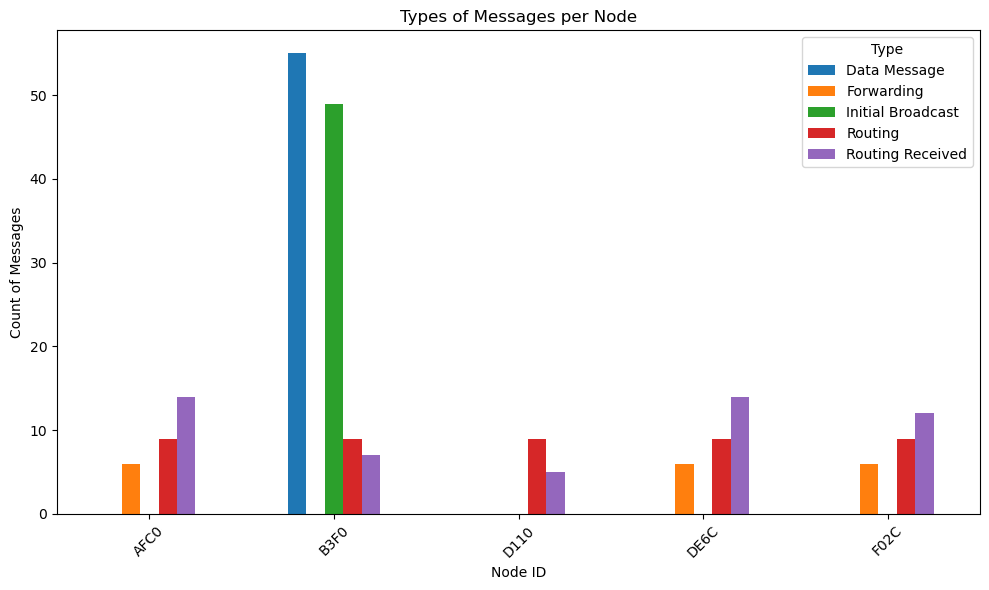

C:\Users\tripa\AppData\Local\Temp\ipykernel_6836\3225359672.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([time_diff[id].dt.total_seconds() for id in time_diff.keys()], labels=time_diff.keys())


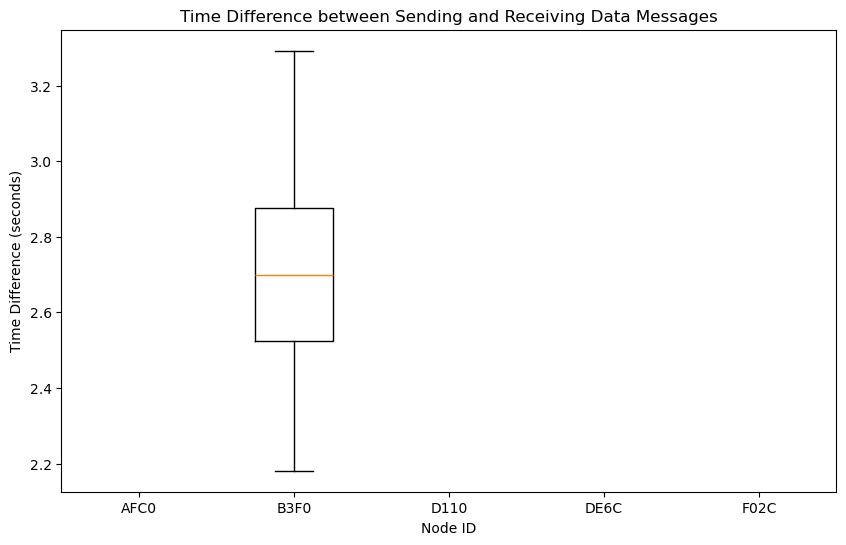

Packet Delivery Ratio (PDR):


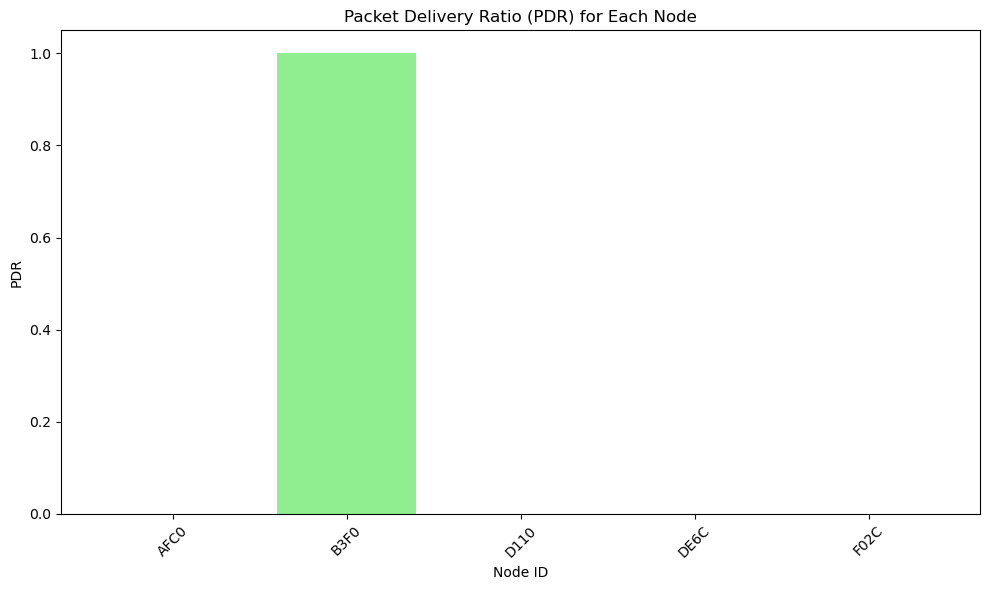

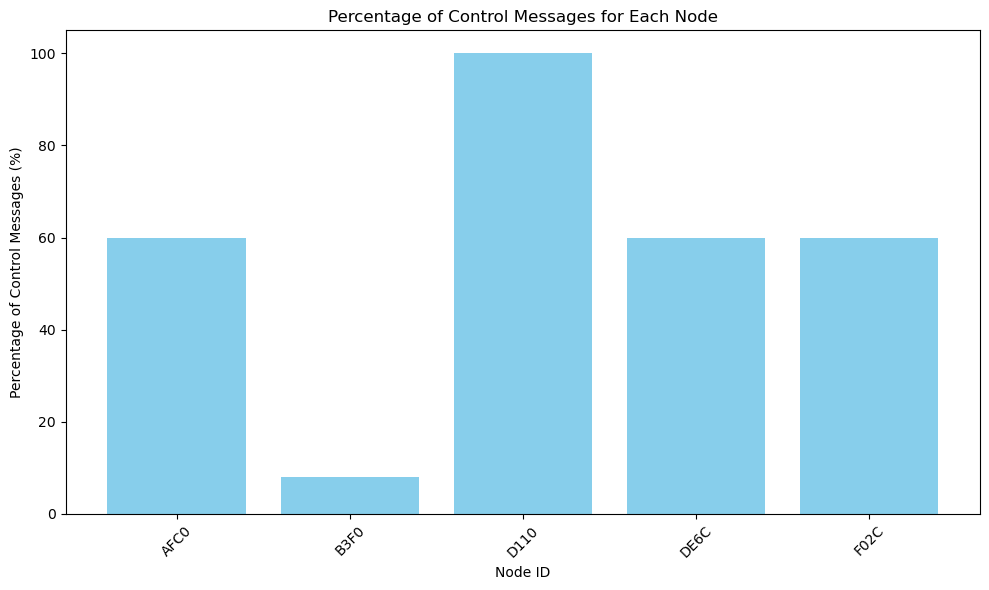

In [ ]:
def analyze(df):
    print("Analyzing DataFrame:")
    print(f"Shape: {df.shape}")

    print(f"Columns: {df.columns.tolist()}")

    print("First few rows:")
    display(df.head())

    print("All Routing Packets Received: ")
    routing_df_rec = df[df['Message'].str.contains('Route packet from')]
    print(routing_df_rec.shape)
    display(routing_df_rec.head())

    print("All Routing Packets Sent: ")
    routing_df_send = df[df['Message'].str.contains('Creating Routing Packet')]
    print(routing_df_send.shape)
    display(routing_df_send.head())

    print("All Forwarding Packets: ")
    forward_df = df[df['Message'].str.contains('Forwarding it')]
    print(forward_df.shape)
    display(forward_df.head())

    print("Initial Broadcast Packets: ")
    initial_broadcast_df = df[df['Message'].str.contains('Sending packet to FFFF')]
    print(initial_broadcast_df.shape)
    display(initial_broadcast_df.head())

    print("Data Messages: ")
    data_msg_df = df[(df['Message'].str.contains('Send packet'))]
    print(data_msg_df.shape)
    display(data_msg_df.head())

    print("Final Messages Sent: ")
    routing_df_send['Type'] = "Routing"
    routing_df_rec['Type'] = "Routing Received"
    forward_df['Type'] = "Forwarding"
    initial_broadcast_df['Type'] = "Initial Broadcast"
    data_msg_df['Type'] = "Data Message"
    df_combined = pd.concat([routing_df_send, routing_df_rec, forward_df, initial_broadcast_df, data_msg_df], ignore_index=True)
    display(df_combined.head())

    print("Types per Node:")
    plt.figure(figsize=(10, 6))

    df_combined.groupby(['Id', 'Type']).size().unstack(fill_value=0).plot(kind='bar', figsize=(10, 6))
    plt.title('Types of Messages per Node')
    plt.xlabel('Node ID')
    plt.ylabel('Count of Messages')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    time_diff = {}
    pdr = {}
    for id in df['Id'].unique():
        msg_sent = df[(df['Id'] == id) & (df['Message'].str.contains(f'Src: {id} Dst: D110'))]
        msg_sent['MsgId'] = msg_sent['Message'].str.extract(r'Id: (\d+)')[0]
        msg_rec = df[(df['Id'] == 'D110') & (df['Message'].str.contains(f'Src: {id} Dst: D110'))] 
        msg_rec['MsgId'] = msg_rec['Message'].str.extract(r'Id: (\d+)')[0]
        pdr[id] = len(msg_rec) / len(msg_sent) if len(msg_sent) > 0 else 0
        merged = pd.merge(msg_sent, msg_rec, on='MsgId', suffixes=('_send', '_rec'))
        time_diff[id] = (merged['Timestamp_rec'] - merged['Timestamp_send'])

    plt.figure(figsize=(10, 6))
    # box plot
    plt.boxplot([time_diff[id].dt.total_seconds() for id in time_diff.keys()], labels=time_diff.keys())
    plt.title('Time Difference between Sending and Receiving Data Messages')
    plt.xlabel('Node ID')
    plt.ylabel('Time Difference (seconds)')
    plt.tight_layout()
    plt.show()

    print("Packet Delivery Ratio (PDR):")
    plt.figure(figsize=(10, 6))
    plt.bar(pdr.keys(), pdr.values(), color='lightgreen')
    plt.title('Packet Delivery Ratio (PDR) for Each Node')
    plt.xlabel('Node ID')
    plt.ylabel('PDR')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # calculate percentage of control messages for each node
    control_messages = df_combined[df_combined['Type'].isin(['Routing'])]
    data_messages = df_combined[df_combined['Type'].isin(['Data Message', 'Forwarding', 'Initial Broadcast'])]

    control_percentage = {}

    for id in df_combined['Id'].unique():
        control_count = control_messages[control_messages['Id'] == id].shape[0]
        data_count = data_messages[data_messages['Id'] == id].shape[0]
        total_count = control_count + data_count
        if total_count > 0:
            percentage_control = (control_count / total_count) * 100
        else:
            percentage_control = 0
        control_percentage[id] = percentage_control
        
    # Plotting the control message percentage
    plt.figure(figsize=(10, 6))
    plt.bar(control_percentage.keys(), control_percentage.values(), color='skyblue')
    plt.title('Percentage of Control Messages for Each Node')
    plt.xlabel('Node ID')
    plt.ylabel('Percentage of Control Messages (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



    
analyze(before_c998)


# After C998 Addition

Analyzing DataFrame:
Shape: (8772, 3)
Columns: ['Timestamp', 'Message', 'Id']
First few rows:


,Timestamp,Message,Id
0,2025-07-29 19:55:58.387,[1097835][V][LoraMesher.cpp:378] receivingRou...,AFC0
1,2025-07-29 19:55:58.397,[1097845][V][LoraMesher.cpp:379] receivingRou...,AFC0
2,2025-07-29 19:55:58.405,[1097852][I][PacketService.cpp:12] createEmpt...,AFC0
3,2025-07-29 19:55:58.414,[1097861][I][LoraMesher.cpp:392] receivingRou...,AFC0
4,2025-07-29 19:55:58.425,[1097872][V][LoraMesher.cpp:647] processPacke...,AFC0


All Routing Packets Received: 
(57, 3)


,Timestamp,Message,Id
297,2025-07-29 19:57:50.895,[1210335][I][RoutingTableService.cpp:77] proc...,AFC0
318,2025-07-29 19:57:51.711,[1211151][I][RoutingTableService.cpp:77] proc...,AFC0
526,2025-07-29 19:59:51.920,[1331353][I][RoutingTableService.cpp:77] proc...,AFC0
697,2025-07-29 20:01:50.459,[1449888][I][RoutingTableService.cpp:77] proc...,AFC0
717,2025-07-29 20:01:51.481,[1450909][I][RoutingTableService.cpp:77] proc...,AFC0


All Routing Packets Sent: 
(37, 3)


...

,Timestamp,Message,Id
1333,2025-07-29 19:55:57.966,Send packet 56,B3F0
1401,2025-07-29 19:56:18.061,Send packet 57,B3F0
1448,2025-07-29 19:56:38.156,Send packet 58,B3F0
1495,2025-07-29 19:56:58.252,Send packet 59,B3F0
1568,2025-07-29 19:57:18.347,Send packet 60,B3F0


Final Messages Sent: 


,Timestamp,Message,Id,Type
0,2025-07-29 19:57:49.115,[1208555][V][LoraMesher.cpp:598] sendHelloPac...,AFC0,Routing
1,2025-07-29 19:59:49.189,[1328623][V][LoraMesher.cpp:598] sendHelloPac...,AFC0,Routing
2,2025-07-29 20:01:49.262,[1448691][V][LoraMesher.cpp:598] sendHelloPac...,AFC0,Routing
3,2025-07-29 20:03:49.334,[1568759][V][LoraMesher.cpp:598] sendHelloPac...,AFC0,Routing
4,2025-07-29 20:05:49.406,[1688827][V][LoraMesher.cpp:598] sendHelloPac...,AFC0,Routing


Types per Node:


<Figure size 1000x600 with 0 Axes>

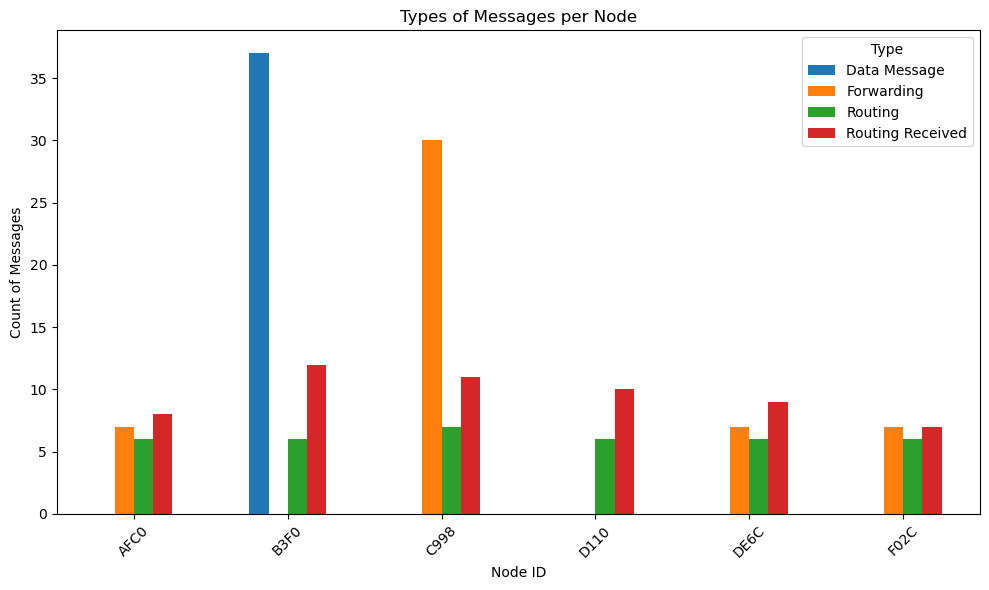

C:\Users\tripa\AppData\Local\Temp\ipykernel_6836\3225359672.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([time_diff[id].dt.total_seconds() for id in time_diff.keys()], labels=time_diff.keys())


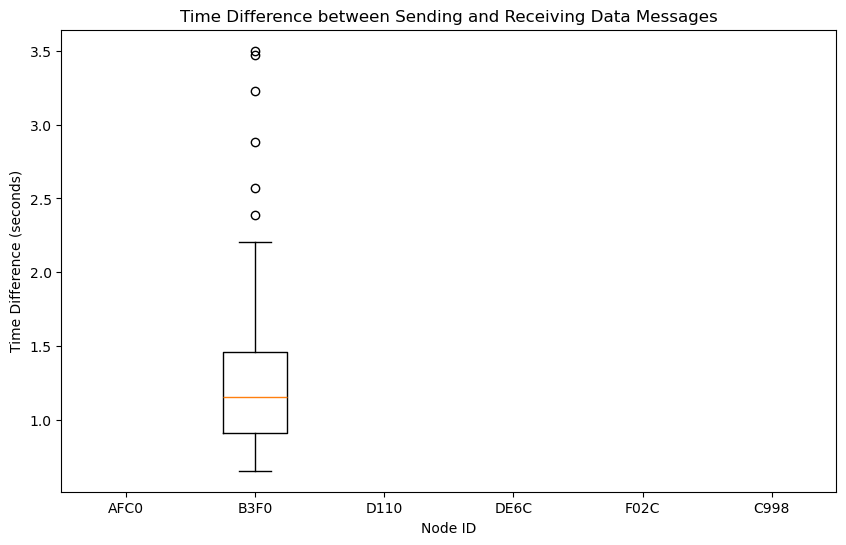

Packet Delivery Ratio (PDR):


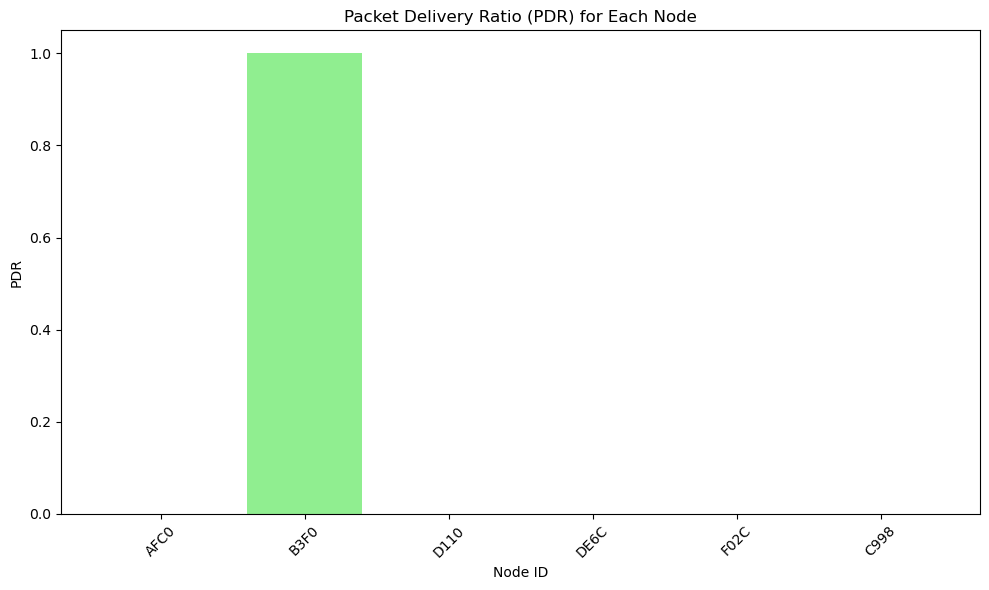

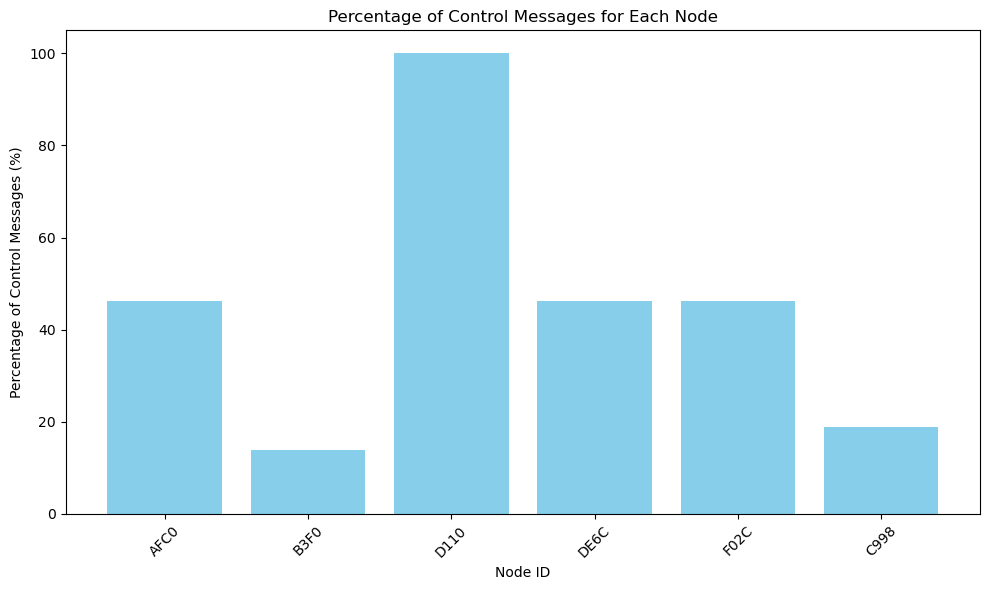

In [20]:
after_c998 = df.copy()
after_c998 = after_c998[after_c998['Timestamp'] >= c998['Timestamp'].min()]
after_c998 = pd.concat([after_c998, c998], ignore_index=True)
analyze(after_c998)